## Overview (26/01/2026)

This notebook is for the purpose of testing/demonstrating the code in aux_funcs/DRT.py.

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import DRT as drt
import pandas as pd

TESTED_LATEST_VERSION = 0.10

In [2]:
# Define a function to give a gaussian distribution of lifetimes about a central lifetime tau on a logarithmic scale
def log_gaussian(tau, mu, sig):
    return 1/(sig*np.sqrt(2*np.pi))*np.exp(-(np.log10(tau/mu))**2/(2*sig**2))

### Capacitive and Inductive Curve Test

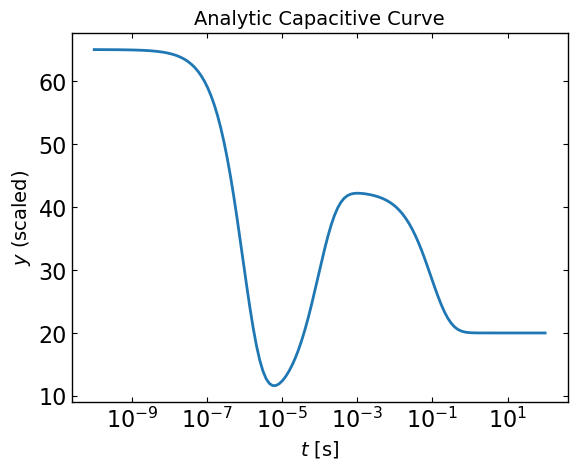

In [3]:
# Generate an array of time values of length N
t_min = 1e-10
t_max = 1e2
time = np.geomspace(t_min, t_max, 140)
time_ppd = int(np.log10(t_max/t_min))

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
d_t = [time[i+1] - time[i] for i in range(len(time)-1)]
d_t_min = np.min(d_t)
d_T = time[-1] - time[0]
tau_min = d_t_min/np.pi   # Selected based on Nyquist spacing
tau_max = d_T/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(d_T/tau_min))
tau_values = np.geomspace(tau_min, tau_max, len(time))

# Generate the analytic curve
gaussian_coeffs = [5, -3, 2]
gaussian_peaks = [1e-6, 1e-4, 1e-1] # These now correspond to when decay events begin
analytic_U = np.sum([gaussian_coeffs[i]*log_gaussian(tau_values, gaussian_peaks[i], 0.2) for i in range(len(gaussian_coeffs))], axis=0)
analytic_y = drt.predict_y_model(time, analytic_U, tau_values) + 20
analytic_y_scaled = (analytic_y - analytic_y.min())/(analytic_y.max() - analytic_y.min())

# Plot the data 
plt.plot(time, analytic_y)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$y$ (scaled)')
plt.title("Analytic Capacitive Curve")
plt.show()

### Linear Fit

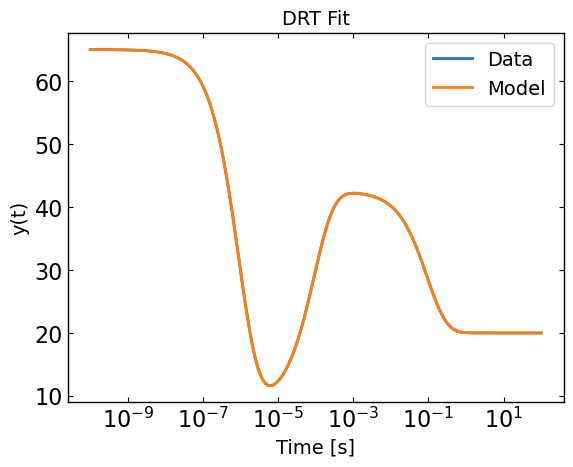

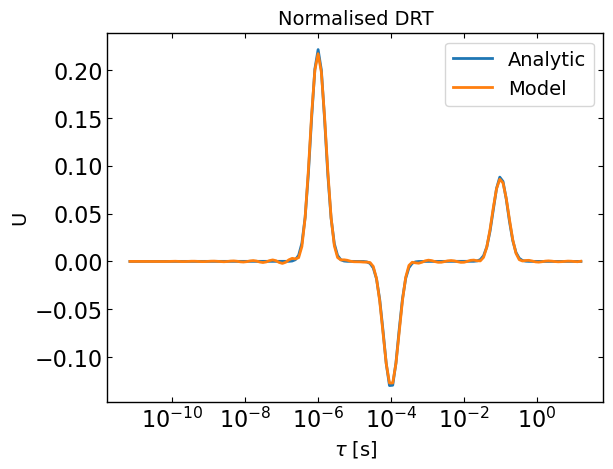

In [4]:
# Try linear fit
linear_fit = drt.linear_fit(time, analytic_y)

# Plot fit results
drt.plot_y(time, linear_fit.y_model, y_data=analytic_y)
drt.plot_U(linear_fit.tau, linear_fit.U_norm, tau_values, analytic_U/np.sum(analytic_U), plot_title='Normalised DRT')

### Checkerboard Fit

In [5]:
fits = drt.checkerboard_fit(time, analytic_y)
cb_fit = fits[-1]

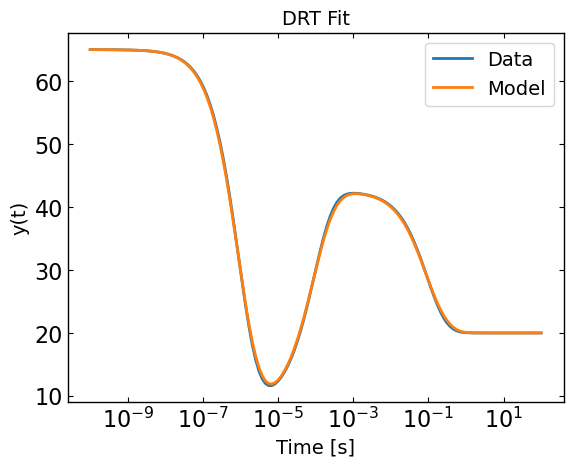

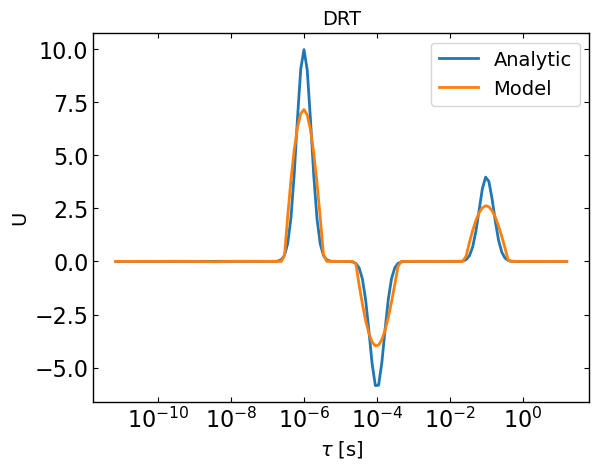

In [6]:
drt.plot_y(time, cb_fit.y_model, analytic_y)
drt.plot_U(cb_fit.tau, cb_fit.U, tau_analytic=tau_values, U_analytic=analytic_U)

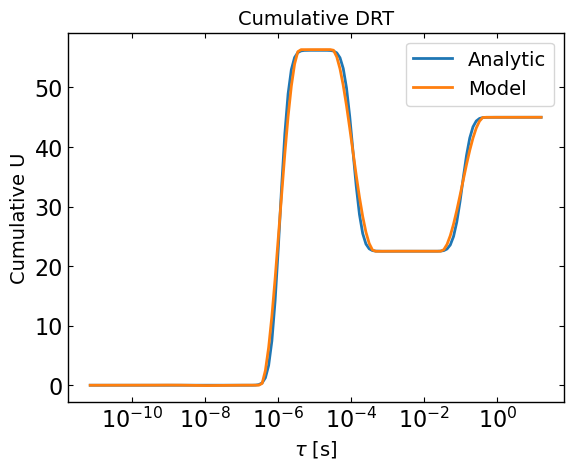

In [7]:
drt.plot_cumulative_U(cb_fit.tau, cb_fit.U, tau_analytic=tau_values, U_analytic=analytic_U)

In [8]:
# Test how y error and DRT error change with number of max iterations for OSQP
cb_fits = drt.checkerboard_fit(time, analytic_y, checkerboard_iters=40, fit_scaling=False)

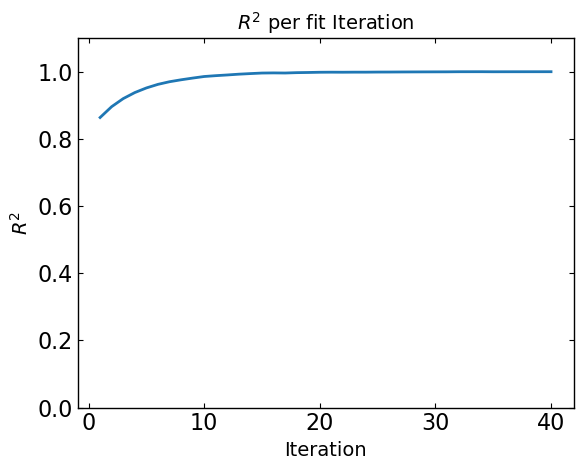

In [9]:
ax = drt.plot_R_2(cb_fits, return_ax=True)


### Analytic and Capacitive

In [10]:
# Define a function to give a gaussian distribution of lifetimes about a central lifetime tau on a logarithmic scale
def log_gaussian(tau, mu, sig):
    return 1/(sig*np.sqrt(2*np.pi))*np.exp(-(np.log10(tau/mu))**2/(2*sig**2))

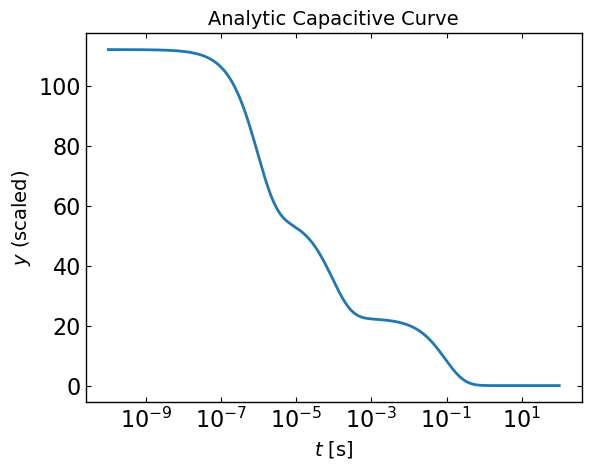

In [11]:
# Generate an array of time values of length N
t_min = 1e-10
t_max = 1e2
time = np.geomspace(t_min, t_max, 1000)
time_ppd = int(np.log10(t_max/t_min))

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
tau_min = t_min/np.pi   # Selected based on Nyquist spacing
tau_max = t_max/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(tau_max/tau_min))
tau_values = np.geomspace(t_min/np.pi, t_max/(2*np.pi), tau_dec*time_ppd)

# Generate the analytic curve
gaussian_coeffs = [5, 3, 2]
gaussian_peaks = [1e-6, 1e-4, 1e-1] # These now correspond to when decay events begin
analytic_U = np.sum([gaussian_coeffs[i]*log_gaussian(tau_values, gaussian_peaks[i], 0.2) for i in range(len(gaussian_coeffs))], axis=0)
analytic_y = drt.predict_y_model(time, analytic_U, tau_values)
analytic_y_scaled = (analytic_y - analytic_y.min())/(analytic_y.max() - analytic_y.min())

# Plot the data 
plt.plot(time, analytic_y)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$y$ (scaled)')
plt.title("Analytic Capacitive Curve")
plt.show()

### Capacitive Curve Test

In [12]:
cb_fits = drt.checkerboard_fit(time, analytic_y)
cb_fit = cb_fits[-1]

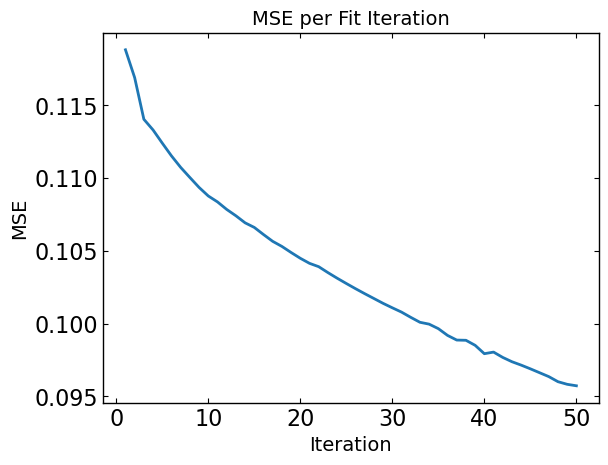

In [13]:
# Plot the error 
drt.plot_MSE(cb_fits)

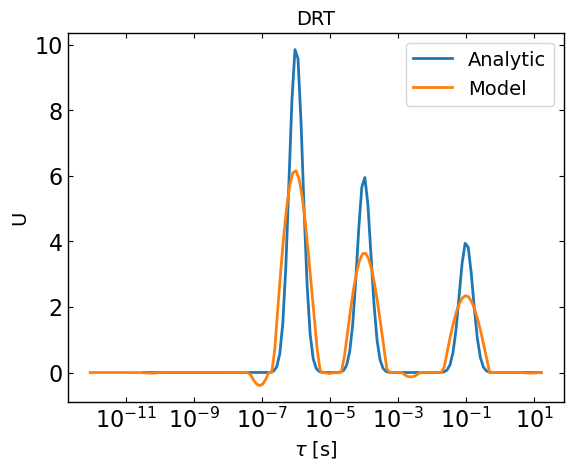

In [14]:
# Plot fitted curves 
drt.plot_U(cb_fit.tau, cb_fit.U, tau_analytic=tau_values, U_analytic=analytic_U)

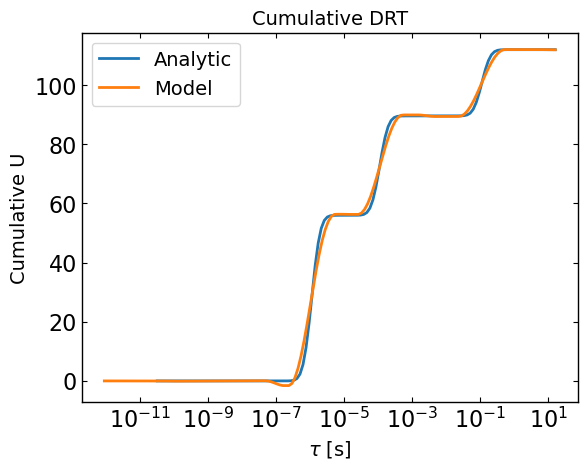

In [15]:
drt.plot_cumulative_U(cb_fit.tau, cb_fit.U, tau_values, analytic_U)

#### Using plotting methods

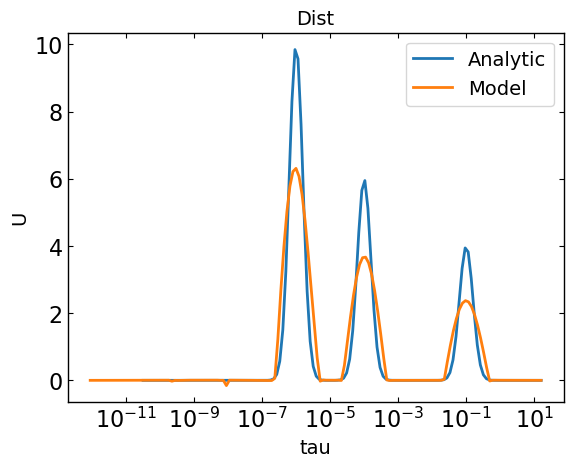

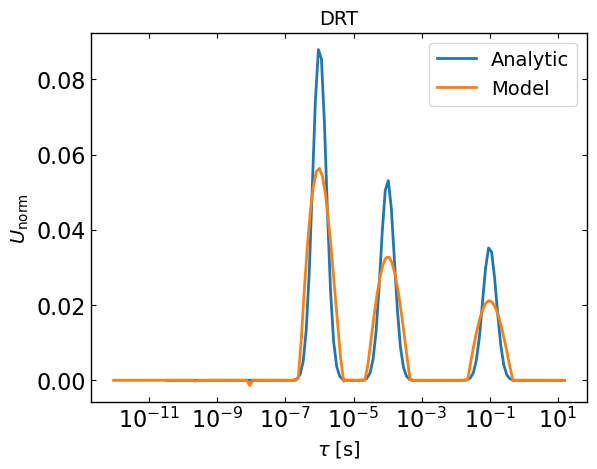

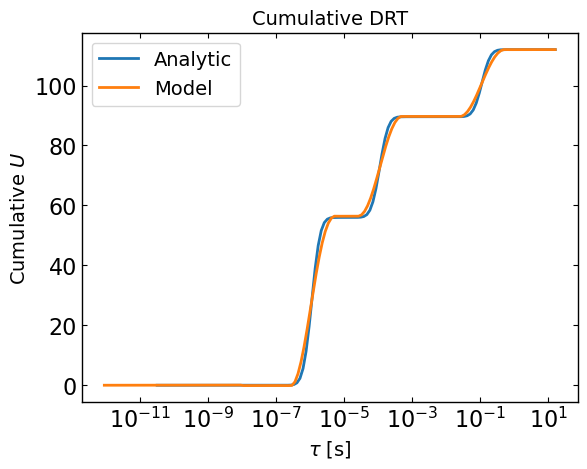

(1e-07, 1e-05)

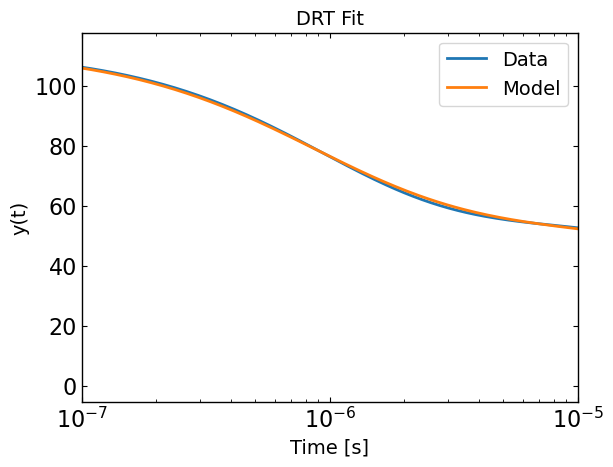

In [16]:
cb_fits[0].plot_U(tau_analytic = tau_values, U_analytic=analytic_U, xaxis_label = "tau", yaxis_label="U", plot_title="Dist")
cb_fits[0].plot_U(normalised=True, tau_analytic = tau_values, U_analytic=analytic_U/np.sum(analytic_U))
cb_fits[0].plot_cumulative_U(tau_analytic = tau_values, U_analytic=analytic_U)
ax = cb_fits[0].plot_y_model(time, analytic_y, return_ax=True)
ax.set_xlim((1e-7, 1e-5))

### Try File Saving and Loading


In [17]:
save_dir = "DRT_Saves"
drt.save_to_txt(save_dir, cb_fits)

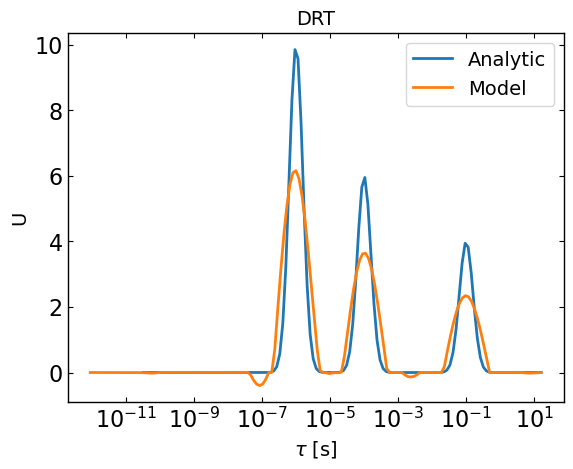

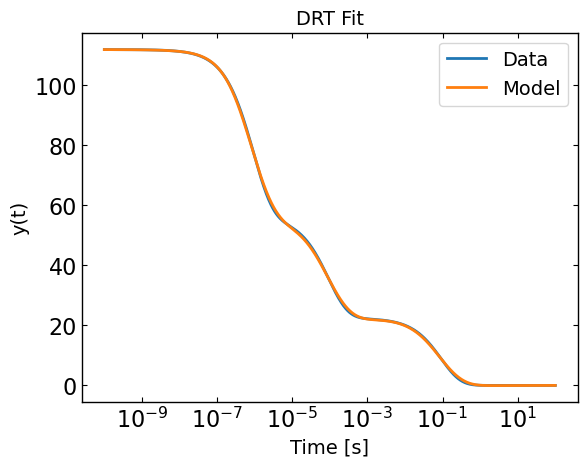

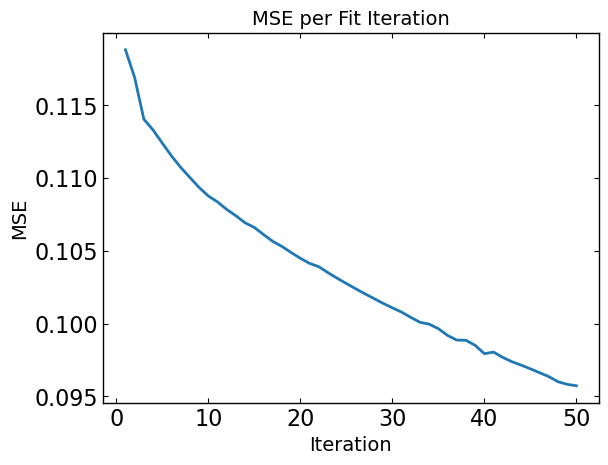

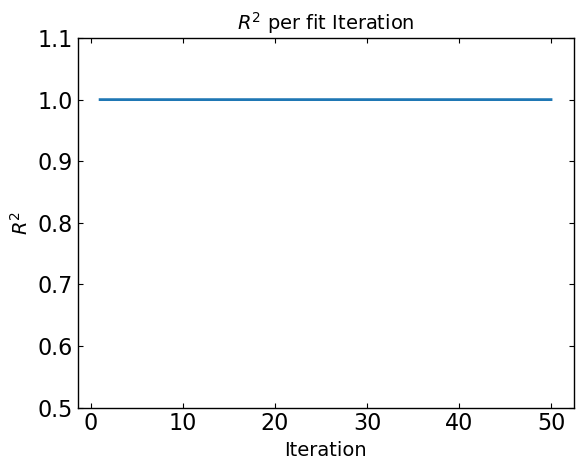

In [18]:
# Try reading in the saved txt files
models = pd.read_csv('DRT_Saves/DRTModels.txt', sep=r'\s+', comment='#')
outputs = pd.read_csv('DRT_Saves/modelOutputs.txt', sep=r'\s+')
errors = pd.read_csv('DRT_Saves/outputErrors.txt', sep=r'\s+')

drt.plot_U(models['tau'], models['U_iter_50'], tau_analytic=tau_values, U_analytic=analytic_U)
drt.plot_y(outputs['t'], outputs['y_model_iter_50'], y_data=analytic_y)
drt.plot_MSE(errors['MSE'])
drt.plot_R_2(errors['R_2'], ylim=(0.5, 1.1))

## Add CLI Test

In [19]:
session_path = os.path.join('../','SIMsalabim','ZimT')
session_path = os.path.abspath(session_path)


In [22]:
DRT_commands_and_args = [
        '-dataFile', session_path + '/' + 'tj.dat', 
        '-DRTDirectory', session_path + '/' + 'DRT_Saves',
        '-timeCol', 't',
        '-funcCol', 'Jext',
        '-iters', '50',
        '-saveFormat', 'txt',
        '-UUID', 'tag'
    ]

DRT_commands_and_args_dict = {
    'dataFile': session_path + '/' + 'tj.dat', 
    'DRTDirectory': session_path + '/' + 'DRT_Saves',
    'timeCol': 't',
    'funcCol': 'Jext',
    'iters': '50',
    'saveFormat': 'txt',
    'UUID': 'tag',
    'startIndex': '',
    'startTime': ''
}

drt.main(DRT_commands_and_args[1:])

Error: dataFile not found. Check file path.


2

In [21]:
DRT_commands_and_args_dict = {
    'dataFile': session_path + '/' + 'tj.dat', 
    'DRTDirectory': session_path + '/' + 'DRT_Saves',
    'timeCol': 't',
    'funcCol': 'Jext',
    'iters': '50',
    'saveFormat': 'json',
    'UUID': 'tag'
}

drt.main(DRT_commands_and_args_dict)

Error: dataFile not found. Check file path.


2